In [2]:
import numpy as np
import matplotlib.pyplot as plt


# Week-3

**Note to Learners**:

- For questions that involve plotting, just enter $0$ as the answer in the portal.
- For numerical questions, there are two parts. The first part expects you to compute some quantity, say a parameter of a machine learning model. The second part will require you to convert this quantity (if it is not a scalar) into a scalar so that it can be entered as the answer on the portal to the corresponding NAT question.



## Dataset

Run the cell given below to generate the data-matrix $\mathbf{X}$, which is of shape $(n, d)$, where $n$ denotes the number of samples and $d$ denotes the number of features. You will be using this dataset for the rest of the assignment.

**Do not edit this cell.**

In [3]:
np.random.seed(0)

N = 2000
data1 = np.random.randn(N//3,2) + np.array([2,2]) # first argument tells how many rows and 2nd one how many columns each obv is taken from same n(0,1) Distribution 
data2 = np.random.randn(N//3,2) + np.array([-3,-3]) # last + '''' is centeshift of data
data3 = np.random.randn(N//3,2) + np.array([-5,3])
X = np.concatenate((data1, data2, data3))
X
# np.random.randn(100 , 2)   ## practise with this code what it does    

array([[ 3.76405235,  2.40015721],
       [ 2.97873798,  4.2408932 ],
       [ 3.86755799,  1.02272212],
       ...,
       [-6.46836696,  3.5764787 ],
       [-4.93469439,  2.2264872 ],
       [-4.60505181,  2.49611011]])

## Problem 1
How many samples are there in the dataset?



## Solution

In [4]:
# Enter your solution here
X.shape

# n = 1998 

(1998, 2)

## Problem 2

How many features are there in the dataset?


## Solution

In [5]:
# Enter your solution here
X.shape
# and d = 2

(1998, 2)

## Problem 3
Plot the dataset using matplotlib.



## Solution

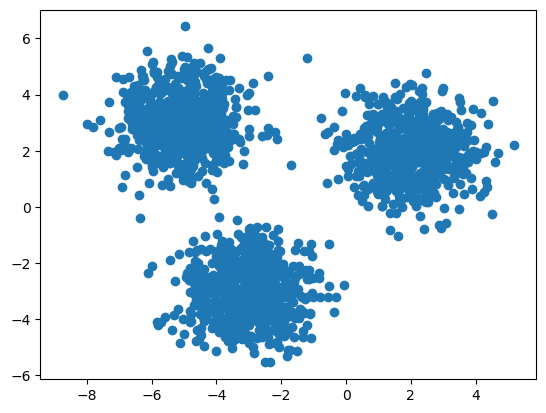

In [6]:
# Enter your solution here

plt.scatter(X[:,0],X[:,1])
plt.show()

## Instruction

Assume k = 3. Take the data points with indices 200, 800 and 1200 in X to be the initial cluster centers.


In [7]:
# Enter your code here
k = 3

center_mat = X[[200 , 800 , 1200] , :  ]  # fancy Indexing

print(center_mat)



[[ 1.40134606  0.88410301]
 [-2.56922887 -3.14989159]
 [-2.84782302 -3.37412632]]


## Problem 4

Write a function `assign_clusters(X, k, cluster_centers)` that assigns a cluster to each data point as per their distance from each cluster centre and returns a vector `z`, where $z[i] \in \{0, 1, 2\}$.

What is the mean of the values in vector `z`? Provide the answer correct up to three decimal places.



## Solution

In [8]:
# Enter your solution here
def assign_clusters(X, k, cluster_centers):
    """
    Assign Each point in X to a cluster center .

    Perameters :
    X : np.ndarray
        Data array of shape (n_samples , d_features)
    K : int
        Number of clusters
    cluster_centers : np.ndarray
                      Array of shape (K rows , d_features) represents cluster centers

    returns :
        z : np.ndarray
            cluster Assignments , where z[i] belongs to {0,1,2,3.....k}
    """

    n = X.shape[0]
    z = np.zeros(n, dtype=int)

    for i in range(n):  # for every DP
        distances = np.zeros(
            k
        )  # distance mat of size k to hold distance of that i th DP form kth cluster in distance
        for j in range(k):
            distances[j] = np.linalg.norm(X[i]- cluster_centers[j])

        z[i] = np.argmin(distances)

    return z

print(assign_clusters(X, 3, center_mat))
print(np.mean(assign_clusters(X, 3, center_mat)) ) 

[0 0 0 ... 1 1 1]
0.7107107107107107


## Problem 5

Plot the data points, with different color for different clusters.


## Solution

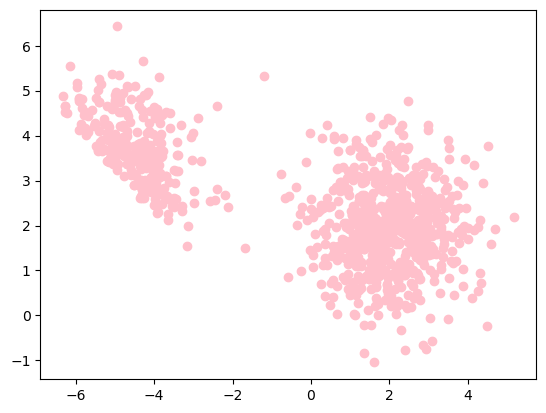

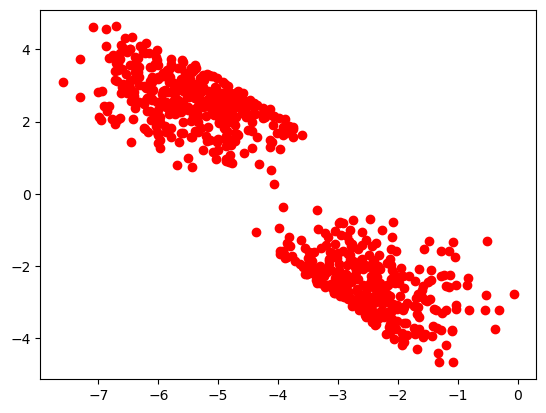

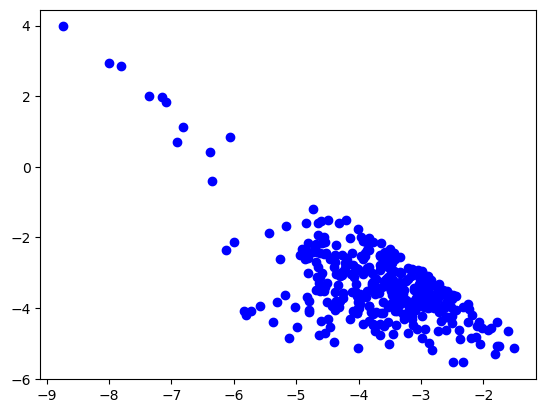

In [9]:
# Enter your solution here
z = assign_clusters(X, 3, center_mat)

Cluster_1_points = X[z==0]
plt.scatter(Cluster_1_points[:,0],Cluster_1_points[:,1],  c = 'pink')
plt.show()
Cluster_2_points = X[z==1]
plt.scatter(Cluster_2_points[:,0],Cluster_2_points[:,1] , c = 'red')
Cluster_3_points = X[z==2]
plt.show()
plt.scatter(Cluster_3_points[:,0],Cluster_3_points[:,1] , c = 'blue')
plt.show()


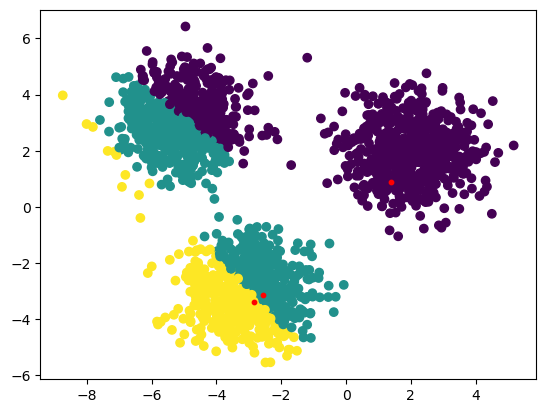

In [10]:
plt.scatter(X[:, 0], X[:, 1], c=z)
plt.scatter(center_mat[:, 0], center_mat[:, 1] , c= "red" , s=10 )
plt.show()

## Problem 6
Write a function `compute_cluster_centers(X, z, k)` that computes the clusters' centers as per z and returns `k` new cluster centers.

What is the mean of the three cluster centers? Provide the $x_1$ and $y_1$ component. Provide both components correct up to three decimal places.



## Solution

In [11]:
# Enter your solution here


def compute_cluster_centers(X, z, k):
    """
    Compute new cluster centers using current cluster assignments.

    Parameters
    ----------
    X : np.ndarray
        Data matrix of shape (n_samples, n_features)

    z : np.ndarray
        Cluster assignments for each data point.
        z[i] contains cluster number assigned to X[i]

    k : int
        Number of clusters

    Returns
    -------
    cluster_centers : np.ndarray
        Matrix of shape (k, n_features)
        Each row contains the mean (center) of one cluster.
    """

    # Number of features (example: x and y => 2)
    d = X.shape[1]

    # Matrix to store new cluster centers
    cluster_centers = np.zeros((k, d))

    # Compute center for each cluster
    for i in range(k):

        # Select all data points belonging to cluster i
        cluster_points = X[z == i]

        # Compute mean of selected points along rows
        cluster_centers[i] = np.mean(cluster_points, axis=0)

    return cluster_centers


# Compute new centers
new_centers = compute_cluster_centers(X, z, 3)

print("Cluster Centers:\n")
print(new_centers)




Cluster Centers:

[[ 0.15243752  2.47002787]
 [-4.09339723  0.26891354]
 [-3.71658966 -3.31569723]]


In [12]:
# Mean of all cluster centers (qustion asked)
mean_center = np.mean(new_centers, axis=0)

print("\nMean of cluster centers:")
print(f"x1 = {mean_center[0]:.3f}")
print(f"y1 = {mean_center[1]:.3f}")



Mean of cluster centers:
x1 = -2.553
y1 = -0.192


## Extra

Keep executing the code in problems 4, 5 and 6 (for, say, 10 iterations) to observe how the clusters change across different iterations.

## Solution

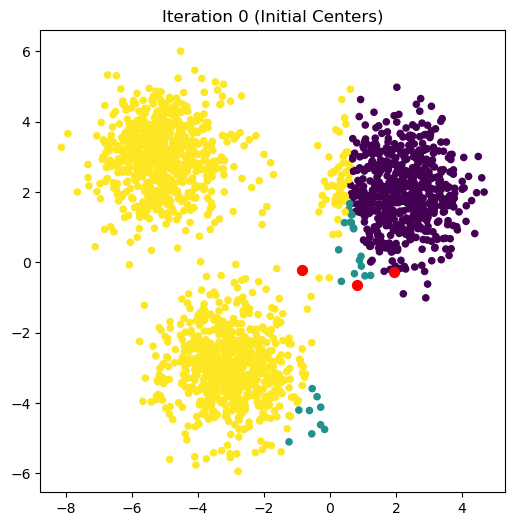


Initial Cluster Centers
[[ 1.93049822 -0.26264472]
 [ 0.8259323  -0.64326701]
 [-0.82898109 -0.20273458]]


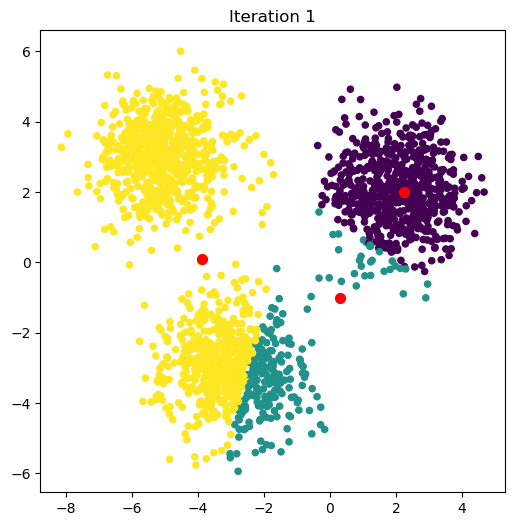


Iteration 1
[[ 2.2349364   2.01363525]
 [ 0.30533292 -1.02392484]
 [-3.86367707  0.09921497]]
Center Shift = 3.8717709710877615


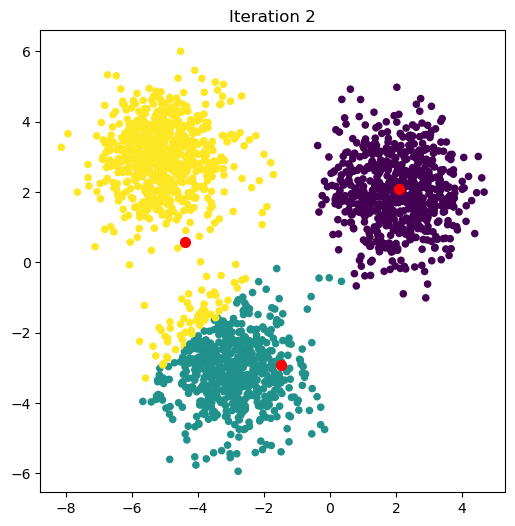


Iteration 2
[[ 2.07781529  2.0910671 ]
 [-1.47028161 -2.91991621]
 [-4.39180769  0.59507656]]
Center Shift = 2.7024199529541733


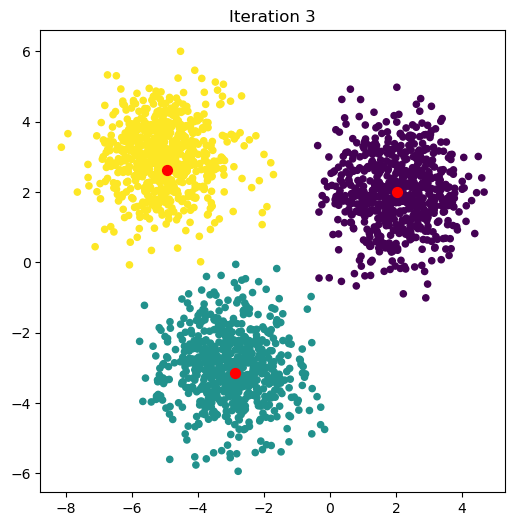


Iteration 3
[[ 2.04521054  2.00486725]
 [-2.87147444 -3.14059214]
 [-4.93884419  2.61814707]]
Center Shift = 2.532310401655044


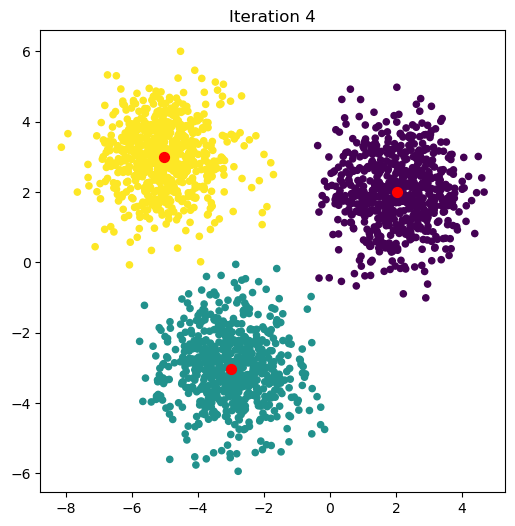


Iteration 4
[[ 2.03600209  1.99370238]
 [-2.99628119 -3.01813102]
 [-5.00701743  2.9851849 ]]
Center Shift = 0.41248909828432906


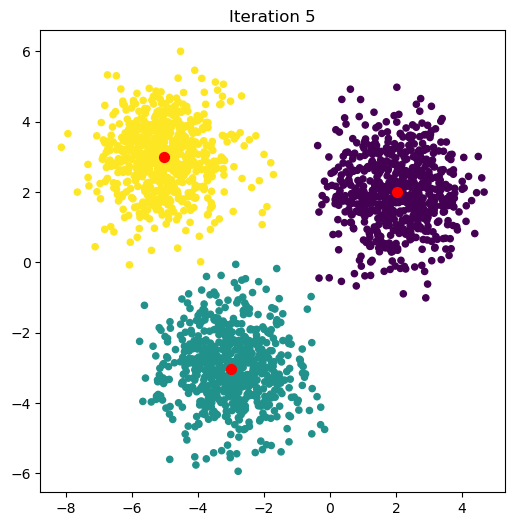


Iteration 5
[[ 2.03600209  1.99370238]
 [-2.99628119 -3.01813102]
 [-5.00701743  2.9851849 ]]
Center Shift = 0.0

K-Means Converged
Stopped at iteration 5


In [13]:
import numpy as np
import matplotlib.pyplot as plt


# -------------------------------
# Step 1 : Generate Example Data
# -------------------------------

N = 2000

# Random Gaussian clusters shifted to different centers
data1 = np.random.randn(N//3, 2) + np.array([2, 2])
data2 = np.random.randn(N//3, 2) + np.array([-3, -3])
data3 = np.random.randn(N//3, 2) + np.array([-5, 3])

# Combine all clusters into one dataset
X = np.concatenate((data1, data2, data3))


# -------------------------------
# Step 2 : Assign Clusters
# -------------------------------

def assign_clusters(X, k, cluster_centers):

    n = X.shape[0]

    # z[i] stores cluster assigned to ith point
    z = np.zeros(n, dtype=int)

    # Iterate over every point
    for i in range(n):

        # Store distance from current point
        # to every cluster center
        distances = np.zeros(k)

        for j in range(k):

            # Euclidean distance
            distances[j] = np.linalg.norm(
                X[i] - cluster_centers[j]
            )

        # Assign nearest cluster
        z[i] = np.argmin(distances)

    return z


# -------------------------------
# Step 3 : Compute New Centers
# -------------------------------

def compute_cluster_centers(X, z, k):

    d = X.shape[1]

    # Matrix to store cluster centers
    cluster_centers = np.zeros((k, d))

    for i in range(k):

        # Select points belonging to cluster i
        cluster_points = X[z == i]

        # Compute mean along columns
        cluster_centers[i] = np.mean(
            cluster_points,
            axis=0
        )

    return cluster_centers


# -------------------------------
# Step 4 : Initial Random Centers
# -------------------------------

k = 3

# Random initial centers
cluster_centers = np.random.randn(k, 2)


# -------------------------------
# Step 5 : Iteration 0
# -------------------------------

z = assign_clusters(X, k, cluster_centers)

plt.figure(figsize=(6,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=z,
    s=20,
    cmap='viridis'
)

plt.scatter(
    cluster_centers[:,0],
    cluster_centers[:,1],
    c='red',
    s=50,
    
)

plt.title("Iteration 0 (Initial Centers)")

plt.show()

print("\nInitial Cluster Centers")
print(cluster_centers)


# -------------------------------
# Step 6 : K-Means Iterations
# -------------------------------

max_iterations = 100

# Convergence threshold
tolerance = 1e-4


for iteration in range(max_iterations):

    # Store old centers
    old_centers = cluster_centers.copy()

    # Step A : Compute new centers
    cluster_centers = compute_cluster_centers(
        X,
        z,
        k
    )

    # Step B : Reassign points
    z = assign_clusters(
        X,
        k,
        cluster_centers
    )

    # ---------------------------
    # Visualization
    # ---------------------------

    plt.figure(figsize=(6,6))

    plt.scatter(
        X[:,0],
        X[:,1],
        c=z,
        s=20,
        cmap='viridis'
    )

    plt.scatter(
        cluster_centers[:,0],
        cluster_centers[:,1],
        c='red',
        s=50,
        
    )

    plt.title(f"Iteration {iteration+1}")

    plt.show()

    # Print current centers
    print(f"\nIteration {iteration+1}")
    print(cluster_centers)

    # ---------------------------
    # Convergence Check
    # ---------------------------

    # Distance moved by centers
    shift = np.linalg.norm(
        cluster_centers - old_centers
    )

    print("Center Shift =", shift)

    # Stop if centers barely move
    if shift < tolerance:

        print("\nK-Means Converged")
        print(f"Stopped at iteration {iteration+1}")

        break